# Notebook 3: Análisis Exploratorio y Correlaciones

**DataJam Edición 4 — Universidad Distrital Francisco José de Caldas**

## Objetivo
Calcular las correlaciones entre pobreza, transporte, violencia y rendimiento educativo. Generar las visualizaciones principales del análisis.

## Hipótesis a evaluar
- H1: Mayor pobreza → mayor dependencia del sector oficial
- H2: Mayor pobreza → peor transporte → mayor inasistencia
- H3: Ingresos precarios → mayor reprobación
- H4: Reprobación → deserción (cadena causal)
- H5: Violencia intrafamiliar → peor rendimiento

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

PROJECT_ROOT = Path(os.path.abspath('.')).resolve()
if '__vsc_ipynb_file__' in dir():
    PROJECT_ROOT = Path(__vsc_ipynb_file__).resolve().parent.parent
else:
    for _ in range(10):
        if (PROJECT_ROOT / 'requirements.txt').exists() and (PROJECT_ROOT / 'scripts').exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

# Cargar tablas integradas del notebook anterior
integrado = pd.read_csv(OUTPUT_DIR / 'tabla_integrada_localidad.csv')
df_deser = pd.read_csv(OUTPUT_DIR / 'desercion_por_upl.csv')

print(f"Tabla integrada: {len(integrado)} localidades")
print(f"Deserción por UPL: {len(df_deser)} UPLs")

Tabla integrada: 17 localidades
Deserción por UPL: 33 UPLs


## 3.1 Serie temporal: IPM vs Indicadores Educativos

In [2]:
# Cargar datos de pobreza para serie temporal
df_pob = pd.read_csv(DATA_DIR / 'pobreza' / 'osb_demografia-pobrezaygini.csv',
                     sep=';', encoding='latin-1')
df_pob.columns = ['Año', 'Localidad', 'Indicador', 'Categoría', 'Sexo', 'Valor']
df_pob['Valor'] = df_pob['Valor'].astype(str).str.replace(',', '.').astype(float)
df_pob['Año'] = df_pob['Año'].astype(int)

# Filtrar Bogotá total, ambos sexos
bogota = df_pob[
    (df_pob['Localidad'].str.contains('Bogot', na=False)) &
    (df_pob['Sexo'].str.contains('Ambos', na=False))
]

ipm = bogota[bogota['Indicador'] == 'IPM'][['Año', 'Valor']].rename(columns={'Valor': 'IPM'})
inasis = bogota[
    (bogota['Indicador'] == 'Privaciones') &
    (bogota['Categoría'] == 'Inasistencia escolar')
][['Año', 'Valor']].rename(columns={'Valor': 'Inasistencia'})
rezago = bogota[
    (bogota['Indicador'] == 'Privaciones') &
    (bogota['Categoría'] == 'Rezago escolar')
][['Año', 'Valor']].rename(columns={'Valor': 'Rezago'})

serie = ipm.merge(inasis, on='Año').merge(rezago, on='Año')
r_rez, p_rez = stats.pearsonr(serie['IPM'], serie['Rezago'])
r_inas, p_inas = stats.pearsonr(serie['IPM'], serie['Inasistencia'])

print(f"Correlación IPM vs Rezago: r={r_rez:.3f}, p={p_rez:.4f}")
print(f"Correlación IPM vs Inasistencia: r={r_inas:.3f}, p={p_inas:.4f}")

Correlación IPM vs Rezago: r=0.783, p=0.0217
Correlación IPM vs Inasistencia: r=0.609, p=0.1094


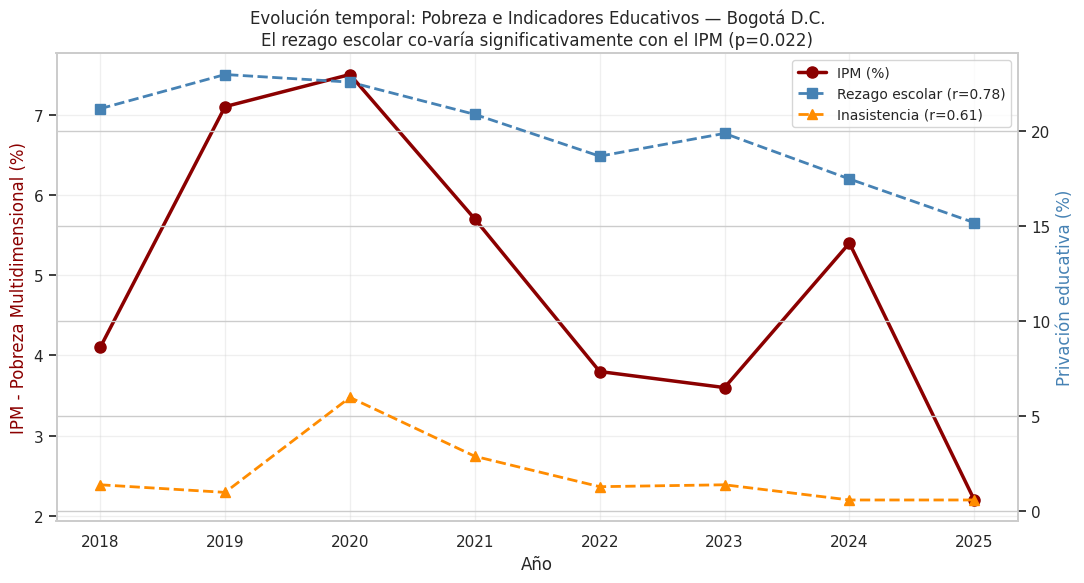

✓ Guardado: output/01_temporal_ipm_educacion.png


In [3]:
# Gráfico de serie temporal
fig, ax1 = plt.subplots(figsize=(11, 6))
ax2 = ax1.twinx()

l1 = ax1.plot(serie['Año'], serie['IPM'], 'o-', color='darkred', linewidth=2.5,
              markersize=8, label='IPM (%)')
l2 = ax2.plot(serie['Año'], serie['Rezago'], 's--', color='steelblue', linewidth=2,
              markersize=7, label=f'Rezago escolar (r={r_rez:.2f})')
l3 = ax2.plot(serie['Año'], serie['Inasistencia'], '^--', color='darkorange', linewidth=2,
              markersize=7, label=f'Inasistencia (r={r_inas:.2f})')

ax1.set_xlabel('Año')
ax1.set_ylabel('IPM - Pobreza Multidimensional (%)', color='darkred')
ax2.set_ylabel('Privación educativa (%)', color='steelblue')
ax1.set_title('Evolución temporal: Pobreza e Indicadores Educativos — Bogotá D.C.\n'
              f'El rezago escolar co-varía significativamente con el IPM (p={p_rez:.3f})')

lines = l1 + l2 + l3
ax1.legend(lines, [l.get_label() for l in lines], loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_temporal_ipm_educacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Guardado: output/01_temporal_ipm_educacion.png')

## 3.2 Pobreza → Matrícula oficial + Presión por sede

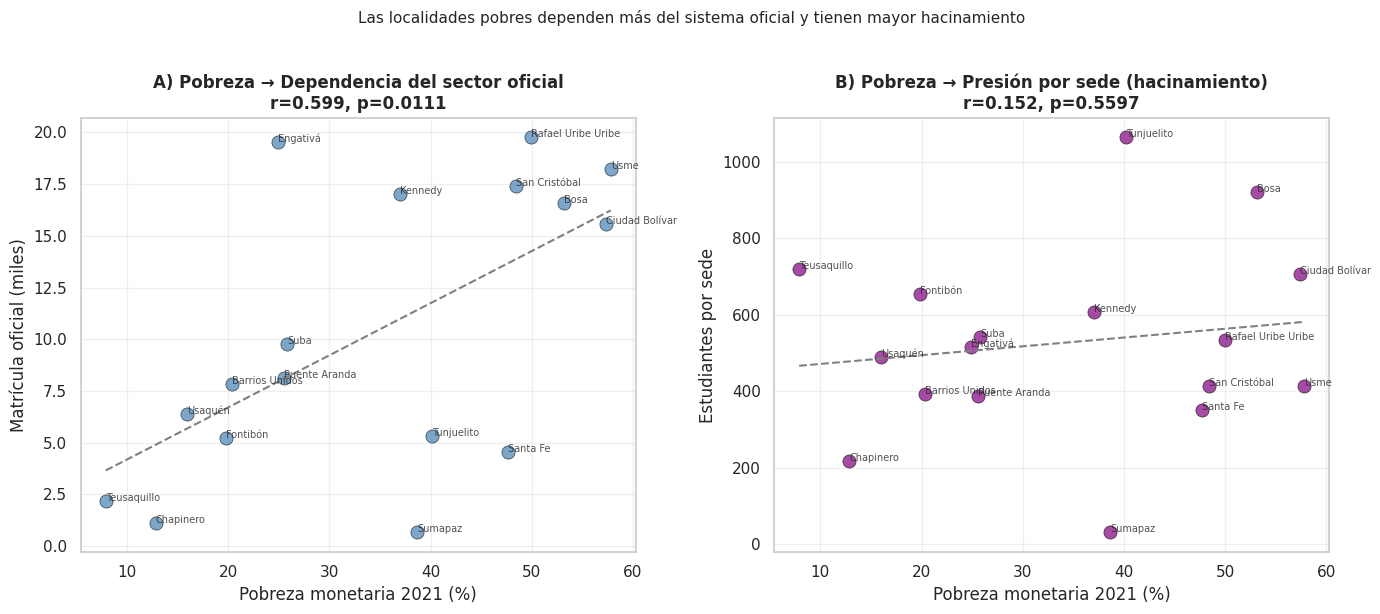

✓ r_matricula=0.599, r_sede=0.152


In [4]:
if 'Matricula' in integrado.columns and integrado['Matricula'].notna().any():
    r_mat, p_mat = stats.pearsonr(integrado['Pobreza_Monetaria'], integrado['Matricula'])
    r_sede, p_sede = stats.pearsonr(integrado['Pobreza_Monetaria'], integrado['Est_por_Sede'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Panel A
    ax = axes[0]
    ax.scatter(integrado['Pobreza_Monetaria'], integrado['Matricula'] / 1000,
              s=90, c='steelblue', alpha=0.7, edgecolors='black', linewidth=0.5)
    z = np.polyfit(integrado['Pobreza_Monetaria'], integrado['Matricula'] / 1000, 1)
    x_r = np.linspace(integrado['Pobreza_Monetaria'].min(), integrado['Pobreza_Monetaria'].max(), 50)
    ax.plot(x_r, np.poly1d(z)(x_r), '--', color='gray', linewidth=1.5)
    for _, row in integrado.iterrows():
        ax.annotate(row['Localidad'], (row['Pobreza_Monetaria'], row['Matricula'] / 1000),
                   fontsize=7, alpha=0.8)
    ax.set_xlabel('Pobreza monetaria 2021 (%)')
    ax.set_ylabel('Matrícula oficial (miles)')
    ax.set_title(f'A) Pobreza → Dependencia del sector oficial\nr={r_mat:.3f}, p={p_mat:.4f}',
                fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Panel B
    ax2 = axes[1]
    ax2.scatter(integrado['Pobreza_Monetaria'], integrado['Est_por_Sede'],
              s=90, c='purple', alpha=0.7, edgecolors='black', linewidth=0.5)
    z2 = np.polyfit(integrado['Pobreza_Monetaria'], integrado['Est_por_Sede'], 1)
    ax2.plot(x_r, np.poly1d(z2)(x_r), '--', color='gray', linewidth=1.5)
    for _, row in integrado.iterrows():
        ax2.annotate(row['Localidad'], (row['Pobreza_Monetaria'], row['Est_por_Sede']),
                    fontsize=7, alpha=0.8)
    ax2.set_xlabel('Pobreza monetaria 2021 (%)')
    ax2.set_ylabel('Estudiantes por sede')
    ax2.set_title(f'B) Pobreza → Presión por sede (hacinamiento)\nr={r_sede:.3f}, p={p_sede:.4f}',
                 fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Las localidades pobres dependen más del sistema oficial y tienen mayor hacinamiento',
                fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '02_pobreza_matricula_presion.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ r_matricula={r_mat:.3f}, r_sede={r_sede:.3f}')
else:
    print('⚠ Datos de matrícula no disponibles. Descarga el dataset de matrícula.')

## 3.3 Reprobación → Deserción (cadena causal)

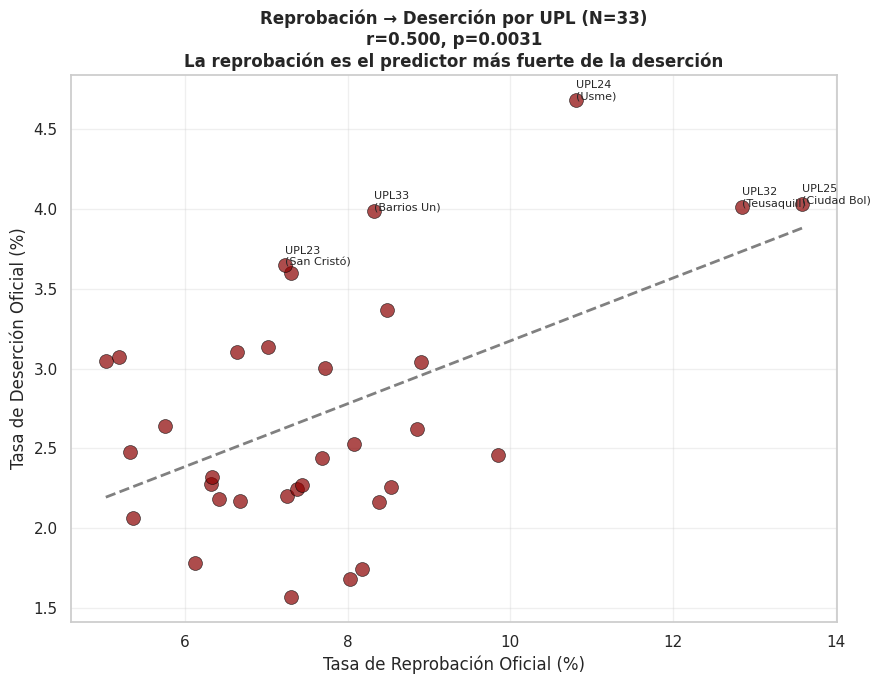


✓ Correlación Reprobación→Deserción: r=0.500, p=0.0031


In [5]:
r_rd, p_rd = stats.pearsonr(df_deser['Reprobacion_Of'], df_deser['Desercion_Of'])

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(df_deser['Reprobacion_Of'], df_deser['Desercion_Of'],
           s=100, c='darkred', alpha=0.7, edgecolors='black', linewidth=0.5)
z = np.polyfit(df_deser['Reprobacion_Of'], df_deser['Desercion_Of'], 1)
x_r = np.linspace(df_deser['Reprobacion_Of'].min(), df_deser['Reprobacion_Of'].max(), 50)
ax.plot(x_r, np.poly1d(z)(x_r), '--', color='gray', linewidth=2)

# Anotar las 5 UPLs con mayor deserción
for _, row in df_deser.nlargest(5, 'Desercion_Of').iterrows():
    ax.annotate(f"{row['Cod_UPL']}\n({str(row.get('Localidad') or row['NOM_UPL'])[:10]})",
               (row['Reprobacion_Of'], row['Desercion_Of']),
               fontsize=8, ha='left')

ax.set_xlabel('Tasa de Reprobación Oficial (%)', fontsize=12)
ax.set_ylabel('Tasa de Deserción Oficial (%)', fontsize=12)
ax.set_title(f'Reprobación → Deserción por UPL (N={len(df_deser)})\n'
             f'r={r_rd:.3f}, p={p_rd:.4f}\n'
             'La reprobación es el predictor más fuerte de la deserción',
             fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_reprobacion_desercion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✓ Correlación Reprobación→Deserción: r={r_rd:.3f}, p={p_rd:.4f}')

## 3.4 Resumen de correlaciones encontradas

In [6]:
print("RESUMEN DE CORRELACIONES")
print("=" * 60)
print(f"{'Relación':45s} {'r':>6s}  {'p':>8s}  {'Sig.'}")
print("-" * 60)
print(f"{'IPM vs Rezago escolar (temporal)':45s} {r_rez:>6.3f}  {p_rez:>8.4f}  {'**' if p_rez < 0.01 else '*' if p_rez < 0.05 else 'ns'}")
print(f"{'IPM vs Inasistencia (temporal)':45s} {r_inas:>6.3f}  {p_inas:>8.4f}  {'**' if p_inas < 0.01 else '*' if p_inas < 0.05 else 'ns'}")
if 'Matricula' in integrado.columns and integrado['Matricula'].notna().any():
    print(f"{'Pobreza → Matrícula oficial':45s} {r_mat:>6.3f}  {p_mat:>8.4f}  {'**' if p_mat < 0.01 else '*' if p_mat < 0.05 else 'ns'}")
    print(f"{'Pobreza → Est. por sede':45s} {r_sede:>6.3f}  {p_sede:>8.4f}  {'**' if p_sede < 0.01 else '*' if p_sede < 0.05 else 'ns'}")
print(f"{'Reprobación → Deserción (UPL)':45s} {r_rd:>6.3f}  {p_rd:>8.4f}  {'***' if p_rd < 0.001 else '**' if p_rd < 0.01 else '*' if p_rd < 0.05 else 'ns'}")
print("\n** p<0.01  * p<0.05  ns: no significativo")

RESUMEN DE CORRELACIONES
Relación                                           r         p  Sig.
------------------------------------------------------------
IPM vs Rezago escolar (temporal)               0.783    0.0217  *
IPM vs Inasistencia (temporal)                 0.609    0.1094  ns
Pobreza → Matrícula oficial                    0.599    0.0111  *
Pobreza → Est. por sede                        0.152    0.5597  ns
Reprobación → Deserción (UPL)                  0.500    0.0031  **

** p<0.01  * p<0.05  ns: no significativo


## Siguiente paso
→ Notebook 04: Análisis de transporte, violencia y conclusiones finales.